# Sentivols — FNSPID Daily Pipeline
## 5 Annotation Methods × Daily PortfolioManager Simulation

**Dataset**: [FNSPID](https://huggingface.co/datasets/Zihan1004/FNSPID) — 15.7M financial news records for S&P-500 companies (1999–2023).  
**Goal**: Study whether financial news sentiment, processed with increasingly sophisticated NLP methods, produces a viable long-only equity portfolio.  

### Annotation variants benchmarked
| # | Method | Normalizer backend | Text source |
|---|---|---|---|
| 1 | **VADER** | None | article headline |
| 2 | **VADER + LLM** | `VLLMBackend` (Qwen 2.5-7B) | full article body |
| 3 | **VADER + Transformer** | `TransformersBackend` (flan-t5-xl) | full article body |
| 4 | **VADER + LlamaCpp** | `LlamaCppBackend` (Q4_K_M GGUF) | full article body |
| 5 | **VADER + RAG** | `FinancialRAGNormalizer` | article headline |

### Temporal splits
| Split | Period | ym boundary |
|---|---|---|
| Train | 1999 – 2016 | date ≤ 2016-12-31 |
| Validation | 2017 – 2018 | 2016-12-31 < date ≤ 2018-12-31 |
| Test | 2019 – 2023 | date > 2018-12-31 (includes COVID-19) |

### Information maturation rule
News published on day **t** affects the market on day **t+1** →  
all sentiment features use a **1-day lag** before joining to returns.  No forward-looking information leaks into the model.

## §0 — Colab Setup

In [1]:
# ── Detect runtime environment ─────────────────────────────────────────────
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print('Environment: Google Colab' if IN_COLAB else 'Environment: Local')

# ── Confirm GPU ────────────────────────────────────────────────────────────
import subprocess, sys
if IN_COLAB:
    !nvidia-smi
    gpu_info = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
        capture_output=True, text=True,
    ).stdout.strip()
    print('GPU found:', gpu_info)
else:
    print('GPU check skipped (local environment).')


Environment: Google Colab
Tue Apr  7 16:08:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   45C    P8             17W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

GPU found: NVIDIA L4, 23034 MiB


In [2]:
import os


DRIVE_ROOT = os.getcwd()

os.makedirs(f'{DRIVE_ROOT}/cache',   exist_ok=True)
os.makedirs(f'{DRIVE_ROOT}/figures', exist_ok=True)
os.makedirs(f'{DRIVE_ROOT}/models',  exist_ok=True)
print('DRIVE_ROOT:', DRIVE_ROOT)


DRIVE_ROOT: /content


In [3]:
## ── Make sentvols importable + install all dependencies ──────────────────
import sys, subprocess, pathlib

def _pip(*args):
    """Run pip as a subprocess; print stderr so failures are visible."""
    result = subprocess.run(
        [sys.executable, "-m", "pip", *args],
        capture_output=True, text=True,
    )
    if result.stdout.strip():
        print(result.stdout.strip()[-1000:])
    if result.returncode != 0:
        print(result.stderr.strip()[-2000:])
        raise RuntimeError(f"pip {list(args)} failed (exit {result.returncode})")

# ── Make sentvols importable ──────────────────────────────────────────────
try:
    import sentvols  # noqa: F401
    print("sentvols already importable:", sentvols.__file__)
except ImportError:
    if IN_COLAB:
        REPO_DIR = "/content/sentvols_repo"
        if not pathlib.Path(REPO_DIR).exists():
            print("Cloning sentvols repo …")
            subprocess.run(
                ["git", "clone", "--depth=1",
                 "https://github.com/Seydifa/sentvols.git", REPO_DIR],
                check=True,
            )
            print("Cloned.")
        else:
            print("Repo already cloned — pulling latest …")
            subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)
        if REPO_DIR not in sys.path:
            sys.path.insert(0, REPO_DIR)
        import sentvols  # noqa: F401
        print("sentvols importable via sys.path:", sentvols.__file__)
    else:
        raise RuntimeError("sentvols not found. Activate your local venv and try again.")

# ── Core deps (always installed; skip torch/accelerate/bitsandbytes on Colab
#    to avoid triggering a kernel restart) ───────────────────────────────────
print("Installing / upgrading core packages …")
_pip(
    "install", "-q", "--upgrade",
    "huggingface_hub>=0.20",
    "yfinance>=1.0",
    "polars>=0.20",
    "sentencepiece",
    "pandas>=2.0",
    "matplotlib>=3.7",
    "seaborn>=0.13",
    "scipy>=1.11",
    "tqdm>=4.64",
    "vaderSentiment>=3.3.2",
    "optuna>=3.0",
    "lightgbm>=4.0",
    "scikit-learn>=1.3",
    "sentence-transformers>=2.7",
    "vllm"
)

# ── Heavy GPU deps — installed only when NOT on Colab L4 (already present) ──
if not IN_COLAB:
    print("Installing GPU / transformer packages …")
    _pip(
        "install", "-q",
        "transformers>=4.40",
        "accelerate>=0.27",
        "bitsandbytes",
        "vllm",
    )

print("All dependencies ready.")


Repo already cloned — pulling latest …
sentvols importable via sys.path: /content/sentvols_repo/sentvols/__init__.py
Installing / upgrading core packages …
All dependencies ready.


In [4]:
# ── Download FNSPID dataset via Hugging Face Hub ──────────────────────────
import os
from huggingface_hub import hf_hub_download

RAW_DIR  = f'{DRIVE_ROOT}/cache'
NEWS_CSV = f'{RAW_DIR}/nasdaq_exteral_data.csv'

if not os.path.exists(NEWS_CSV):
    print('Downloading FNSPID news CSV (~2.5 GB) from Hugging Face Hub …')
    _downloaded = hf_hub_download(
        repo_id   = 'Zihan1004/FNSPID',
        filename  = 'Stock_news/nasdaq_exteral_data.csv',
        repo_type = 'dataset',
        local_dir = RAW_DIR,
        local_dir_use_symlinks = False,
    )
    # hf_hub_download places the file in a sub-folder; create a flat alias
    if _downloaded != NEWS_CSV:
        import shutil
        shutil.move(_downloaded, NEWS_CSV)
    print(f'Download complete → {NEWS_CSV}')
else:
    print(f'News CSV already cached at {NEWS_CSV}')


News CSV already cached at /content/cache/nasdaq_exteral_data.csv


## §1 — Configuration

In [5]:
# ── Standard library & third-party imports ────────────────────────────────
import gc, os, warnings

import numpy as np
import pandas as pd
import polars as pl
import torch
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 100

print('Imports OK')


Imports OK


### §1b — Hyperparameters & Paths

In [6]:
# ── Temporal split boundaries ─────────────────────────────────────────────
TRAIN_END_DATE = '2016-12-31'   # <= this date → training
VAL_END_DATE   = '2018-12-31'   # <= this date (and > TRAIN_END) → validation
# test: > VAL_END_DATE  (2019-01-01 to 2023-12-31 — includes COVID-19)

# ── Universe & portfolio scoping ──────────────────────────────────────────
TOP_N_TICKERS    = 150     # top tickers by article volume
PORTFOLIO_N      = 50      # long-only top-N per day

# ── Trading simulation ────────────────────────────────────────────────────
INITIAL_CASH     = 1_000_000.0
TRANSACTION_COST = 0.001   # 10 bps round-trip

# ── Model training ────────────────────────────────────────────────────────
HPO_TRIALS       = 60      # Optuna trials per model
PERM_N           = 500     # permutation test replicates
ROLL_VOL_DAYS    = 20      # rolling volatility window

# ── Demo mode: cap articles for fast testing (set False for full run) ─────
DEMO_MODE        = False
DEMO_ROWS        = 100_000

# ── Annotation method names ───────────────────────────────────────────────
METHODS = ['VADER', 'VADER+LLM', 'VADER+Transformer', 'VADER+LlamaCpp', 'VADER+RAG']

# ── Derived paths ─────────────────────────────────────────────────────────
FIG_DIR        = f'{DRIVE_ROOT}/figures'
CACHE_DIR      = f'{DRIVE_ROOT}/cache'
NEWS_CSV       = f'{CACHE_DIR}/nasdaq_exteral_data.csv'
PRICES_PARQUET = f'{CACHE_DIR}/prices_top150.parquet'
GGUF_PATH      = f'{DRIVE_ROOT}/models/qwen2.5-1.5b-instruct-q4_k_m.gguf'

print(f'Config OK  |  demo={DEMO_MODE}  top_tickers={TOP_N_TICKERS}  port_n={PORTFOLIO_N}')
print(f'Splits     |  train ≤ {TRAIN_END_DATE}  |  val ≤ {VAL_END_DATE}  |  test > {VAL_END_DATE}')


Config OK  |  demo=False  top_tickers=150  port_n=50
Splits     |  train ≤ 2016-12-31  |  val ≤ 2018-12-31  |  test > 2018-12-31


## §2 — Data Loading & EDA

In [7]:
# ── Load FNSPID CSV ────────────────────────────────────────────────────────
# Peek at column names first (handles both 'title' and 'article' variants)
cols_preview = pd.read_csv(NEWS_CSV, nrows=0).columns.tolist()
print('CSV columns:', cols_preview)

# Identify the headline and body column names dynamically
HEADLINE_COL = 'Article_title'
BODY_COL     = 'Article'
TICKER_COL   = 'Stock_symbol' 
DATE_COL     = 'Date'

print(f'Using: headline={HEADLINE_COL!r}  body={BODY_COL!r}  ticker={TICKER_COL!r}  date={DATE_COL!r}')

# Lazy-scan the CSV with Polars
_lf = pl.scan_csv(NEWS_CSV, infer_schema_length=20_000)
if DEMO_MODE:
    _lf = _lf.head(DEMO_ROWS)

df_raw = (
    _lf
    .with_columns([
        pl.col(DATE_COL)
          .str.slice(0, 10)
          .str.to_date(format='%Y-%m-%d', strict=False)
          .alias('date_only'),
        pl.col(TICKER_COL).alias('ticker').str.to_uppercase().str.strip_chars(),
        pl.col(HEADLINE_COL).alias('headline'),
    ])
    .with_columns(
        pl.col(BODY_COL).alias('body') if BODY_COL != HEADLINE_COL
        else pl.col(HEADLINE_COL).alias('body')
    )
    .filter(
        pl.col('headline').is_not_null() &
        pl.col('date_only').is_not_null() &
        pl.col('ticker').is_not_null() &
        pl.col('body').is_not_null()
    )
    .select(['date_only', 'ticker', 'headline', 'body'])
    .collect()
)

print(f'Loaded: {len(df_raw):,} rows  |  date range: {df_raw["date_only"].min()} → {df_raw["date_only"].max()}')
print(f'Unique tickers: {df_raw["ticker"].n_unique()}')

CSV columns: ['Unnamed: 0', 'Date', 'Article_title', 'Stock_symbol', 'Url', 'Publisher', 'Author', 'Article', 'Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']
Using: headline='Article_title'  body='Article'  ticker='Stock_symbol'  date='Date'
Loaded: 2,491,778 rows  |  date range: 2009-04-08 → 2024-01-09
Unique tickers: 4694


In [8]:
# ── Filter to top-N tickers by article volume ─────────────────────────────
ticker_counts = (
    df_raw.group_by('ticker')
    .agg(pl.len().alias('n_articles'))
    .sort('n_articles', descending=True)
    .head(TOP_N_TICKERS)
)
TOP_TICKERS = ticker_counts['ticker'].to_list()
df_news = df_raw.filter(pl.col('ticker').is_in(TOP_TICKERS))

print(f'After filter: {len(df_news):,} rows | {df_news["ticker"].n_unique()} tickers')
print('Top-10 tickers by article count:')
print(ticker_counts.head(10).to_pandas().to_string(index=False))

After filter: 1,029,205 rows | 150 tickers
Top-10 tickers by article count:
ticker  n_articles
 BROGW       10456
 BPYPO        9979
 BHFAL        9614
     T        9449
  PMAY        9108
 ACGLO        9014
  DNOV        8990
  GSEE        8966
   AMD        8959
  FDEV        8891


### §2b — Exploratory Data Analysis

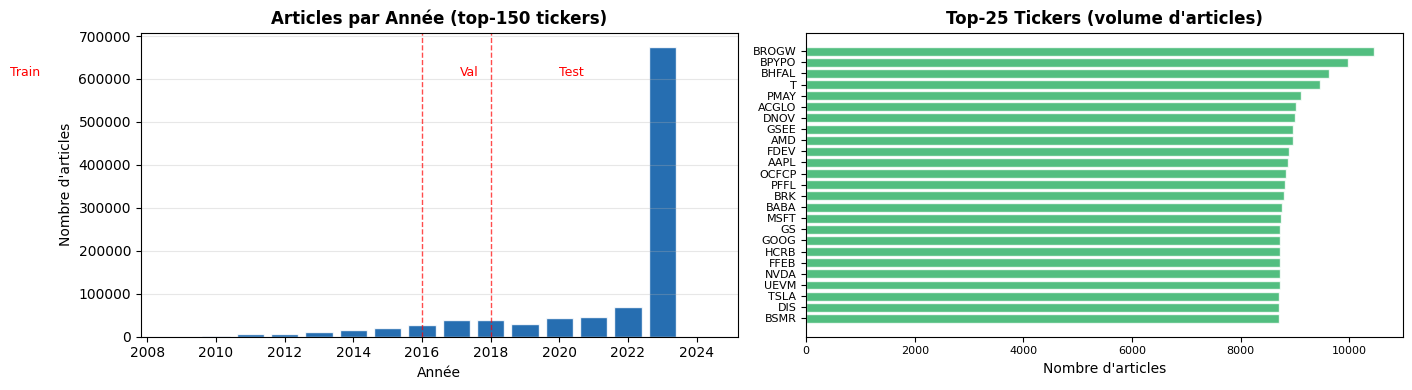

In [9]:
# ── EDA: articles per day & per year ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# articles per year
by_year = (
    df_news.with_columns(pl.col('date_only').dt.year().alias('year'))
    .group_by('year').agg(pl.len().alias('n'))
    .sort('year').to_pandas()
)
axes[0].bar(by_year['year'], by_year['n'], color='#0055A4', alpha=0.85, edgecolor='white')
axes[0].set_title('Articles par Année (top-150 tickers)', fontweight='bold')
axes[0].set_xlabel('Année'); axes[0].set_ylabel('Nombre d\'articles')
axes[0].grid(alpha=0.3, axis='y')
for yr in [2016, 2018]:  # split boundaries
    axes[0].axvline(yr, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0].text(2004, by_year['n'].max()*0.9, 'Train', color='red', fontsize=9)
axes[0].text(2017.1, by_year['n'].max()*0.9, 'Val', color='red', fontsize=9)
axes[0].text(2020, by_year['n'].max()*0.9, 'Test', color='red', fontsize=9)

# top-25 tickers
top25 = ticker_counts.head(25).to_pandas()
axes[1].barh(top25['ticker'][::-1], top25['n_articles'][::-1], color='#27ae60', alpha=0.8, edgecolor='white')
axes[1].set_title('Top-25 Tickers (volume d\'articles)', fontweight='bold')
axes[1].set_xlabel('Nombre d\'articles')
axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/00_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## §3 — Price Download & Log Returns

In [10]:
from sentvols.utils import download_stock_prices

# Download / load from cache
df_prices_raw = download_stock_prices(
    tickers    = TOP_TICKERS,
    start_date = '1999-01-01',
    end_date   = '2023-12-31',
    batch_size = 100,
    cache_path = PRICES_PARQUET,
)

# ── Compute daily log returns ──────────────────────────────────────────────
df_prices = (
    df_prices_raw
    .sort(['ticker', 'date_only'])
    .with_columns(
        (pl.col('close_price') / pl.col('close_price').shift(1).over('ticker')).log()
        .alias('log_return')
    )
    .drop_nulls(subset=['log_return'])
    .rename({'log_return': 'ret'})
)

print(f'Prices: {len(df_prices):,} rows | {df_prices["ticker"].n_unique()} tickers')
print(f'Date range: {df_prices["date_only"].min()} → {df_prices["date_only"].max()}')
df_prices.describe()

Prices: 516,112 rows | 124 tickers
Date range: 1999-01-05 → 2023-12-29


statistic,date_only,ticker,close_price,ret
str,str,str,f64,f64
"""count""","""516112""","""516112""",516112.0,516112.0
"""null_count""","""0""","""0""",0.0,0.0
"""mean""","""2013-02-16 22:59:07.378863""",null,57.669186,0.000325
"""std""",null,null,181.027845,0.024886
"""min""","""1999-01-05""","""AAL""",0.031276,-1.411612
"""25%""","""2007-02-09""",null,12.38,-0.00863
"""50%""","""2013-11-01""",null,25.616295,0.0
"""75%""","""2019-10-04""",null,57.251408,0.00946
"""max""","""2023-12-29""","""XOM""",8125.439941,1.389314


In [11]:
# ── Market index returns (SPY benchmark via yfinance) ─────────────────────
import yfinance as yf

SPY_CACHE = f'{CACHE_DIR}/spy_returns.parquet'
if not os.path.exists(SPY_CACHE):
    spy_raw = yf.download('SPY', start='1999-01-01', end='2023-12-31',
                          auto_adjust=True, progress=False)
    spy_df = (
        pl.from_pandas(
            spy_raw.reset_index()[['Date', 'Close']]
            .droplevel(1, axis=1)
            .rename(columns={'Date': 'date_only', 'Close': 'spy_close'})
            )
        .with_columns(pl.col('date_only').cast(pl.Date))
        .sort('date_only')
        .with_columns(
            (pl.col('spy_close') / pl.col('spy_close').shift(1)).log().alias('mkt_ret')
        )
        .drop_nulls(subset=['mkt_ret'])
        .select(['date_only', 'mkt_ret'])
    )
    spy_df.write_parquet(SPY_CACHE)
else:
    spy_df = pl.read_parquet(SPY_CACHE)

# Rename 'date_only' to 'period' for compatibility with build_full_feature_set
mkt_returns = spy_df.rename({'date_only': 'period'})
print(f'SPY returns: {len(mkt_returns):,} rows')

# Price df also needs 'period' col for build_full_feature_set
df_prices_feat = df_prices.rename({'date_only': 'period'})

SPY returns: 6,288 rows


## §4 — Annotation Loop (6 Variants)


In [ ]:
# ── Helper: annotate with or without normalizer; save/load from cache ─────
from sentvols.core.annotators import FinancialVADERAnnotator
from sentvols.utils import annotate_news

annotator = FinancialVADERAnnotator()


def run_annotation(
    df,
    normalizer,
    method_name,
    text_col='headline',
    batch_size=256,
    workers=1,
    ann=None,
    max_per_period=None,
):
    """Run annotation; returns df_annotated with sentiment_score / sentiment_label.

    Parameters
    ----------
    df : pl.DataFrame
    normalizer : FinancialTextNormalizer | None
        LLM normalizer for VADER+LLM variants; None for pure scoring.
    method_name : str
        Cache key and dict key in `annotated`.
    text_col : str, default 'headline'
        Column used as input text.
    batch_size : int, default 256
        Prompts per backend.batch_call() chunk.
    workers : int, default 1
        Thread-pool size for backends without batch_call().
    ann : annotator | None
        Override the global VADER annotator.
    max_per_period : int | None, default None
        If set, keep only the first N articles per (ticker, date_only)
        before passing to the LLM.  This is the primary knob to control
        LLM runtime: max_per_period=5 reduces ~1 M rows to ~150 tickers
        × ~6000 days × 5 = ~450 K rows worst-case (usually much less due
        to sparse coverage).  VADER is fast enough that None is fine.
    """
    cache_path = f'{CACHE_DIR}/annotated_{method_name.replace("+","_")}.parquet'
    if os.path.exists(cache_path):
        print(f'  [{method_name}] Loading from cache …')
        return pl.read_parquet(cache_path)

    # ── Optional per-(ticker, day) article cap ────────────────────────────
    df_work = df
    if max_per_period is not None:
        n_before = len(df_work)
        df_work = (
            df_work
            .with_columns(
                pl.int_range(pl.len())
                  .over(['ticker', 'date_only'])
                  .alias('_row_in_group')
            )
            .filter(pl.col('_row_in_group') < max_per_period)
            .drop('_row_in_group')
        )
        print(f'  [{method_name}] Capped {n_before:,} → {len(df_work):,} rows '
              f'(max {max_per_period} articles/ticker/day)')

    _ann = ann if ann is not None else annotator
    print(f'  [{method_name}] Annotating {len(df_work):,} rows …')
    df_text = df_work.with_columns(pl.col(text_col).alias('headline'))
    df_ann = annotate_news(
        df_text, _ann,
        normalizer=normalizer,
        batch_size=batch_size,
        workers=workers,
    )
    # Add period column (date_only as string for build_full_feature_set)
    df_ann = df_ann.with_columns(pl.col('date_only').cast(pl.Utf8).alias('period'))
    df_ann.write_parquet(cache_path)
    print(f'  [{method_name}] Done. Cached to {cache_path}')
    return df_ann


def free_gpu():
    """Release GPU memory between variants."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

annotated = {}  # will hold {method_name: pl.DataFrame}


### Variant 1 — Pure VADER
Baseline: headline-level sentiment, no external normalizer.

In [14]:
# ── Variant 1 : Pure VADER (no normalizer) ────────────────────────────────
annotated['VADER'] = run_annotation(df_news, normalizer=None, method_name='VADER', batch_size=2048, workers=4)
print('VADER sample:')
print(annotated['VADER'].select(['date_only','ticker','headline','sentiment_score','sentiment_label']).head(3))

  [VADER] Loading from cache …
VADER sample:
shape: (3, 5)
┌────────────┬────────┬─────────────────────────────────┬─────────────────┬─────────────────┐
│ date_only  ┆ ticker ┆ headline                        ┆ sentiment_score ┆ sentiment_label │
│ ---        ┆ ---    ┆ ---                             ┆ ---             ┆ ---             │
│ date       ┆ str    ┆ str                             ┆ f64             ┆ str             │
╞════════════╪════════╪═════════════════════════════════╪═════════════════╪═════════════════╡
│ 2023-12-16 ┆ AAL    ┆ COLUMN-Funds less negative on … ┆ -0.4951         ┆ négatif         │
│ 2023-12-16 ┆ AAL    ┆ American Airlines (AAL) Rises … ┆ 0.0             ┆ neutre          │
│ 2023-12-16 ┆ AAL    ┆ Southwest Airlines pilots reac… ┆ 0.3182          ┆ positif         │
└────────────┴────────┴─────────────────────────────────┴─────────────────┴─────────────────┘


### Variant 2 — VADER + LLM (vLLM · Qwen 2.5-7B)
Full article body normalized via vLLM before VADER scoring.

In [ ]:
# ── Variant 2 : VADER + LLM normalizer (vLLM · Qwen 2.5-1.5B) ─────────────
# Article body is normalised by the LLM → condensed text → VADER scores it.
# max_per_period=5: keep the 5 most recent articles per (ticker, day)
# → reduces ~1 M rows to ≤ 450 K before LLM inference.
from sentvols.utils import VLLMBackend, FinancialTextNormalizer

vllm_backend = VLLMBackend(
    model='Qwen/Qwen2.5-1.5B-Instruct',
    max_new_tokens=128,
    temperature=0.0,
    gpu_memory_utilization=0.85,
    dtype='bfloat16',
)
vllm_normalizer = FinancialTextNormalizer(vllm_backend)

_text_col_llm = 'body' if 'body' in df_news.columns else 'headline'
annotated['VADER+LLM'] = run_annotation(
    df_news, normalizer=vllm_normalizer,
    method_name='VADER+LLM', text_col=_text_col_llm,
    batch_size=2048,
    max_per_period=5,   # cap: ≤ 5 articles/ticker/day sent to LLM
)

del vllm_backend, vllm_normalizer
free_gpu()
print('VADER+LLM annotation complete.')


  [VADER+LLM] Annotating 1,029,205 rows …


Rendering prompts:   0%|          | 0/2048 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2048 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

Rendering prompts:   0%|          | 0/2048 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2048 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

Rendering prompts:   0%|          | 0/2048 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2048 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

Rendering prompts:   0%|          | 0/2048 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2048 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

KeyboardInterrupt: 

### Variant 2b — LLM Direct Scoring (vLLM · Qwen 2.5-1.5B)
`FinancialLLMAnnotator` asks Qwen 2.5-7B to emit a float in **[-1, 1]** for each headline — **no VADER**.
`score_batch()` → `VLLMBackend.batch_call()` sends the full batch as a single PagedAttention request.


In [ ]:
# ── Variant 2b : Direct LLM Scoring (FinancialLLMAnnotator + vLLM) ───────
# No VADER — Qwen 2.5-1.5B reads each headline and returns a float in [-1, 1].
# max_per_period=5: same cap as VADER+LLM for consistency.
from sentvols.utils import VLLMBackend, FinancialLLMAnnotator

vllm_score_backend = VLLMBackend(
    model='Qwen/Qwen2.5-1.5B-Instruct',
    max_new_tokens=8,
    temperature=0.0,
    gpu_memory_utilization=0.85,
    dtype='bfloat16',
    use_chat_template=True,
)
llm_annotator = FinancialLLMAnnotator(
    backend=vllm_score_backend,
    pos_threshold=0.05,
    neg_threshold=-0.05,
)

annotated['LLM-Direct'] = run_annotation(
    df_news, normalizer=None, method_name='LLM-Direct',
    text_col='headline', batch_size=512, ann=llm_annotator,
    max_per_period=5,   # cap: ≤ 5 articles/ticker/day sent to LLM
)

del vllm_score_backend, llm_annotator
free_gpu()
print('LLM-Direct annotation complete.')


  [LLM-Direct] Annotating 1,029,205 rows …
ERROR 04-07 16:19:15 [core_client.py:667] Engine core proc EngineCore died unexpectedly, shutting down client.


Rendering prompts:   0%|          | 0/1029205 [00:00<?, ?it/s]

### Variant 3 — VADER + Transformer (flan-t5-xl)
Full article body normalized via `flan-t5-xl` before VADER scoring.

In [ ]:
# ── Variant 3 : VADER + Transformer normalizer (flan-t5-base) ─────────────
# Switched from flan-t5-xl → flan-t5-base:
#   250 M params vs 3 B → 4-5× faster per batch, ~600 MB vs ~12 GB VRAM.
#   Summarisation quality is slightly lower but adequate for financial
#   sentence normalisation tasks at this scale.
# max_per_period=5: same cap as LLM variants.
import torch as _torch
from sentvols.utils import TransformersBackend, FinancialTextNormalizer

t5_backend = TransformersBackend(
    model='google/flan-t5-base',
    device_map='auto',
    torch_dtype=_torch.bfloat16,
    max_new_tokens=128,
)
t5_normalizer = FinancialTextNormalizer(t5_backend)

annotated['VADER+Transformer'] = run_annotation(
    df_news, normalizer=t5_normalizer,
    method_name='VADER+Transformer', text_col='body',
    batch_size=1024,
    max_per_period=5,   # cap: ≤ 5 articles/ticker/day sent to T5
)

del t5_backend, t5_normalizer
free_gpu()
print('VADER+Transformer annotation complete.')


### Variant 4 — VADER + LlamaCpp (Qwen 2.5-1.5B Q4_K_M GGUF)
Lightweight local GGUF inference via `llama.cpp`; full GPU offload.

In [ ]:
# ── Variant 4 : VADER + LlamaCpp normalizer (Qwen 2.5-1.5B Q4_K_M GGUF) ──
# LlamaCppBackend has no batch_call(); workers=2 runs two concurrent calls.
# max_per_period=3: stricter cap because LlamaCpp is single-request sequential
# even with workers — 3 articles/ticker/day keeps runtime manageable.
from huggingface_hub import hf_hub_download
from sentvols.utils import LlamaCppBackend, FinancialTextNormalizer

if not os.path.exists(GGUF_PATH):
    print('Downloading GGUF model (~1 GB) …')
    _downloaded = hf_hub_download(
        repo_id='Qwen/Qwen2.5-1.5B-Instruct-GGUF',
        filename='qwen2.5-1.5b-instruct-q4_k_m.gguf',
        local_dir=f'{DRIVE_ROOT}/models',
        local_dir_use_symlinks=False,
    )
    print('Downloaded to:', _downloaded)
else:
    print('GGUF model already cached.')

gguf_backend = LlamaCppBackend(
    model_path=GGUF_PATH,
    n_ctx=1024,
    n_gpu_layers=-1,
    max_tokens=128,
)
gguf_normalizer = FinancialTextNormalizer(gguf_backend)

annotated['VADER+LlamaCpp'] = run_annotation(
    df_news, normalizer=gguf_normalizer,
    method_name='VADER+LlamaCpp', text_col='body',
    workers=2,
    max_per_period=3,   # stricter cap for sequential backend
)

del gguf_backend, gguf_normalizer
free_gpu()
print('VADER+LlamaCpp annotation complete.')


### Variant 5 — VADER + RAG Normalizer
CPU-based retrieval-augmented normalizer using `sentence-transformers`.

In [ ]:
# ── Variant 5 : VADER + RAG normalizer (CPU; sentence-transformers) ───────
from sentvols.utils import FinancialRAGNormalizer

rag_normalizer = FinancialRAGNormalizer()  # uses all-MiniLM-L6-v2 by default

annotated['VADER+RAG'] = run_annotation(
    df_news, normalizer=rag_normalizer,
    method_name='VADER+RAG', text_col='headline',
    workers=1,   # CPU-based retrieval — sequential is fast enough
)

print('VADER+RAG annotation complete.')
print('All 6 annotations ready:', list(annotated.keys()))


### §4b — Sentiment Distribution per Method

In [ ]:
# ── Sentiment distribution per method (combined figure) ───────────────────
from sentvols.plots import plot_sentiment_distribution

for method, df_ann in annotated.items():
    df_pd = df_ann.select(['sentiment_score', 'sentiment_label']).to_pandas()
    fig = plot_sentiment_distribution(
        df_pd,
        save_path=f'{FIG_DIR}/01_sent_dist_{method.replace("+","_")}.png'
    )
    fig.suptitle(f'Sentiment Distribution — {method}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## §5 — Daily Feature Engineering

In [ ]:
from sentvols.features import (
    build_full_feature_set,
    compute_market_betas,
    add_abnormal_returns,
    SENTIMENT_FEATURE_COLS,
)

# ── Feature engineering per variant ───────────────────────────────────────
# build_full_feature_set expects col_period='period' — our df_ann already has it.
# We use col_period='period' for both df_annotated and df_prices_feat.

df_features = {}   # {method: pl.DataFrame with SENTIMENT_FEATURE_COLS + ret + abnormal_ret}

for method, df_ann in annotated.items():
    cache_path = f'{CACHE_DIR}/features_{method.replace("+","_")}.parquet'
    if os.path.exists(cache_path):
        print(f'  [{method}] Loading features from cache …')
        df_features[method] = pl.read_parquet(cache_path)
        continue

    print(f'  [{method}] Building daily features …')
    df_full = build_full_feature_set(
        df_annotated  = df_ann,
        df_prices     = df_prices_feat,
        mkt_returns   = mkt_returns,
        col_ticker    = 'ticker',
        col_period    = 'period',
        col_score     = 'sentiment_score',
        col_label     = 'sentiment_label',
        col_price_ret = 'ret',
        col_mkt       = 'mkt_ret',
        min_beta_obs  = 20,
    )

    # ── 1-day information lag: shift all sentiment features by +1 day ─────
    # News on day t → features for model trained to predict return on day t+1
    sent_cols_to_lag = list(SENTIMENT_FEATURE_COLS)
    df_full = (
        df_full
        .sort(['ticker', 'period'])
        .with_columns([
            pl.col(c).shift(1).over('ticker').alias(c)
            for c in sent_cols_to_lag if c in df_full.columns
        ])
    )

    # ── Rolling 20-day volatility ─────────────────────────────────────────
    df_full = df_full.with_columns(
        pl.col('ret')
          .rolling_std(window_size=ROLL_VOL_DAYS)
          .over('ticker')
          .alias('roll_vol_20')
    )

    # ── Return lags (1 and 2 days) ────────────────────────────────────────
    df_full = df_full.with_columns([
        pl.col('ret').shift(1).over('ticker').alias('ret_lag1'),
        pl.col('ret').shift(2).over('ticker').alias('ret_lag2'),
    ])

    # ── Next-day return target (t+1) ──────────────────────────────────────
    df_full = df_full.with_columns([
        pl.col('ret').shift(-1).over('ticker').alias('target_return'),
    ])
    df_full = df_full.with_columns(
        (pl.col('target_return') > 0).cast(pl.Int32).alias('target_class')
    )

    # ── Drop rows with null targets / lags ────────────────────────────────
    drop_cols = ['target_return', 'ret_lag1', 'ret_lag2'] + sent_cols_to_lag[:3]
    df_full = df_full.drop_nulls(subset=[c for c in drop_cols if c in df_full.columns])

    df_full.write_parquet(cache_path)
    df_features[method] = df_full
    print(f'  [{method}] Features: {len(df_full):,} rows | cols: {len(df_full.columns)}')

print('Feature engineering complete.')

# Show feature columns
sample_method = list(df_features.keys())[0]
print('\nFeature columns (sample method):', df_features[sample_method].columns)

In [ ]:
# ── EDA plots using the VADER variant as reference ────────────────────────
from sentvols.plots import (
    plot_market_betas,
    plot_abnormal_returns,
    plot_sentiment_features_overview,
    plot_correlation_analysis,
    plot_intrastock_scatter,
)

_ref_df = df_features['VADER'].to_pandas()

# Market betas (from VADER features; same for all variants since prices don't change)
_beta_df = (
    compute_market_betas(df_features['VADER'], col_period='period', min_obs=20)
    .to_pandas()
)
plot_market_betas(_beta_df, save_path=f'{FIG_DIR}/02_market_betas.png')

# Abnormal returns distribution
plot_abnormal_returns(_ref_df, col_ret='ret', col_ar='abnormal_ret',
                      save_path=f'{FIG_DIR}/03_abnormal_returns.png')

# Sentiment features overview (VADER variant)
plot_sentiment_features_overview(_ref_df, save_path=f'{FIG_DIR}/04_sent_features_overview.png')

# Correlation analysis — requires daily corr per ticker
_corr_df = (
    df_features['VADER'].to_pandas()
    .groupby('ticker')
    .apply(lambda g: pd.Series({
        'corr_sum':  g['mean_score'].corr(g['target_return']),
        'corr_mean': g['median_score'].corr(g['target_return']),
        'n_points':  len(g.dropna(subset=['mean_score','target_return']))
    }))
    .reset_index()
)
plot_correlation_analysis(_corr_df, save_path=f'{FIG_DIR}/05_correlation_analysis.png')
plot_intrastock_scatter(_corr_df, save_path=f'{FIG_DIR}/06_intrastock_scatter.png')

## §6 — Daily Train / Val / Test Splits

In [ ]:
from sklearn.preprocessing import RobustScaler, StandardScaler

# ── Daily feature columns used for ML models ──────────────────────────────
DAILY_FEATURE_COLS = list(SENTIMENT_FEATURE_COLS) + ['ret_lag1', 'ret_lag2', 'roll_vol_20']
# Remove any column not present in all variants (handle gracefully)
DAILY_FEATURE_COLS = [
    c for c in DAILY_FEATURE_COLS
    if all(c in df_features[m].columns for m in METHODS)
]
print(f'Final feature set ({len(DAILY_FEATURE_COLS)} cols):', DAILY_FEATURE_COLS)


def prepare_daily_splits(df_feat_pl, feature_cols):
    """Temporal train/val/test split on daily sentvols features.

    Scaler is fit ONLY on train → no lookahead in scaling.
    Returns a dict compatible with SentvolsClassifier / SentvolsRegressor.
    """
    df = df_feat_pl.to_pandas()
    df['period'] = pd.to_datetime(df['period'])
    df[feature_cols] = df[feature_cols].fillna(0.0)

    TRAIN_END = pd.Timestamp(TRAIN_END_DATE)
    VAL_END   = pd.Timestamp(VAL_END_DATE)

    mask_train = df['period'] <= TRAIN_END
    mask_val   = (df['period'] > TRAIN_END) & (df['period'] <= VAL_END)
    mask_test  = df['period'] > VAL_END

    X_tr  = df.loc[mask_train, feature_cols].values
    X_val = df.loc[mask_val,   feature_cols].values
    X_te  = df.loc[mask_test,  feature_cols].values

    y_cls_tr  = df.loc[mask_train, 'target_class'].values
    y_cls_val = df.loc[mask_val,   'target_class'].values
    y_cls_te  = df.loc[mask_test,  'target_class'].values

    y_reg_tr  = df.loc[mask_train, 'target_return'].values
    y_reg_val = df.loc[mask_val,   'target_return'].values
    y_reg_te  = df.loc[mask_test,  'target_return'].values

    sc_clf = StandardScaler().fit(X_tr)
    sc_reg = RobustScaler().fit(X_tr)

    df_test_meta = (
        df.loc[mask_test, ['ticker', 'period', 'target_return', 'close_price']]
        .rename(columns={'period': 'period_dt', 'target_return': 'fwd_log_ret'})
        .reset_index(drop=True)
    )
    df_test_meta['period'] = df_test_meta['period_dt'].dt.strftime('%Y-%m-%d')

    for split, mask in [('Train', mask_train), ('Val', mask_val), ('Test', mask_test)]:
        n = mask.sum()
        pos = df.loc[mask, 'target_class'].mean()
        print(f'  {split:6s}: {n:>8,} rows | {df.loc[mask,"ticker"].nunique():3d} tickers | class+=  {pos:.1%}')

    return dict(
        feature_cols=feature_cols,
        df_full=df,
        X_tr_sc=sc_clf.transform(X_tr), X_val_sc=sc_clf.transform(X_val), X_te_sc=sc_clf.transform(X_te),
        X_tr_reg=sc_reg.transform(X_tr), X_val_reg=sc_reg.transform(X_val), X_te_reg=sc_reg.transform(X_te),
        y_cls_tr=y_cls_tr, y_cls_val=y_cls_val, y_cls_te=y_cls_te,
        y_reg_tr=y_reg_tr, y_reg_val=y_reg_val, y_reg_te=y_reg_te,
        df_test_meta=df_test_meta,
        sc_clf=sc_clf, sc_reg=sc_reg,
    )


splits = {}
for method in METHODS:
    print(f'\n[{method}]')
    splits[method] = prepare_daily_splits(df_features[method], DAILY_FEATURE_COLS)

## §7 — HPO, Model Training & Test Evaluation

In [ ]:
from lightgbm import LGBMClassifier, LGBMRegressor
from sentvols.models import SentvolsClassifier, SentvolsRegressor

def lgbm_clf_space(trial):
    return dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 20, 100),
        min_child_samples= trial.suggest_int('min_child_samples', 20, 200),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        verbosity=-1, random_state=42,
    )

def lgbm_reg_space(trial):
    return dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves       = trial.suggest_int('num_leaves', 20, 100),
        min_child_samples= trial.suggest_int('min_child_samples', 20, 200),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        verbosity=-1, random_state=42,
    )

trained_models = {}  # {method: {'clf': ..., 'reg': ..., 'metrics': {...}}}

for method in METHODS:
    print(f'\n── {method} ── HPO + Training ──────────────────────────────────')
    sp = splits[method]

    # ── Classifier ──────────────────────────────────────────────────────
    clf_wrapper = SentvolsClassifier(LGBMClassifier(), random_state=42)
    clf_hpo = clf_wrapper.optimize(
        sp['X_tr_sc'], sp['y_cls_tr'],
        sp['X_val_sc'], sp['y_cls_val'],
        search_space=lgbm_clf_space,
        n_trials=HPO_TRIALS,
    )
    clf_wrapper.fit(sp['X_tr_sc'], sp['y_cls_tr'])
    clf_val_metrics  = clf_wrapper.evaluate(sp['X_val_sc'], sp['y_cls_val'])
    clf_test_metrics = clf_wrapper.evaluate(sp['X_te_sc'],  sp['y_cls_te'])
    print(f'  CLF  val  F1={clf_val_metrics["f1"]:.4f}  |  test F1={clf_test_metrics["f1"]:.4f}')

    # ── Regressor ───────────────────────────────────────────────────────
    from sklearn.metrics import mean_squared_error, r2_score
    reg_wrapper = SentvolsRegressor(LGBMRegressor(), random_state=42)
    reg_hpo = reg_wrapper.optimize(
        sp['X_tr_reg'], sp['y_reg_tr'],
        sp['X_val_reg'], sp['y_reg_val'],
        search_space=lgbm_reg_space,
        n_trials=HPO_TRIALS,
    )
    reg_wrapper.fit(sp['X_tr_reg'], sp['y_reg_tr'])
    y_pred_reg = reg_wrapper.predict(sp['X_te_reg'])
    reg_test_metrics = dict(
        rmse=float(np.sqrt(mean_squared_error(sp['y_reg_te'], y_pred_reg))),
        r2  =float(r2_score(sp['y_reg_te'], y_pred_reg)),
    )
    print(f'  REG  test RMSE={reg_test_metrics["rmse"]:.6f}  R²={reg_test_metrics["r2"]:.4f}')

    trained_models[method] = dict(
        clf=clf_wrapper, reg=reg_wrapper,
        clf_test=clf_test_metrics, reg_test=reg_test_metrics,
    )

print('\nAll models trained.')

In [ ]:
# ── Feature importance plots ───────────────────────────────────────────────
from sentvols.plots import plot_feature_importance

for method in METHODS:
    clf = trained_models[method]['clf']
    reg = trained_models[method]['reg']
    fig = plot_feature_importance(
        clf, reg, DAILY_FEATURE_COLS,
        save_path=f'{FIG_DIR}/07_feat_imp_{method.replace("+","_")}.png'
    )
    fig.suptitle(f'Feature Importance — {method}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## §8 — OLS Econometric Test (Market-Adjusted)

In [ ]:
from sentvols.explainers import test_ols_sentiment_impact
from sentvols.plots import plot_ols_sentiment_results

ols_results = {}
for method in METHODS:
    df_full = df_features[method].to_pandas()
    df_full['period'] = pd.to_datetime(df_full['period'])
    df_test_ols = df_full[df_full['period'] > pd.Timestamp(VAL_END_DATE)]

    ols_res = test_ols_sentiment_impact(
        df_test_ols,
        feature_cols=list(SENTIMENT_FEATURE_COLS),
        col_dep='abnormal_ret',
        intercept=False,
        alpha_level=0.05,
    )
    ols_results[method] = ols_res
    n_sig = int(np.array(ols_res['significant']).sum())
    print(f'[{method}]  n_obs={ols_res["n_obs"]:,}  R²={ols_res["r_squared"]:.4f}  '
          f'F={ols_res["f_stat"]:.2f}  p(F)={ols_res["f_pvalue"]:.4f}  '
          f'sig_features={n_sig}/{len(SENTIMENT_FEATURE_COLS)}')

    fig = plot_ols_sentiment_results(
        ols_res, save_path=f'{FIG_DIR}/08_ols_{method.replace("+","_")}.png'
    )
    fig.suptitle(f'OLS — {method}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## §9 — PortfolioManager Daily Trading Loop

In [ ]:
from sentvols.portfolio import PortfolioBuilder, PortfolioManager

# ── Build per-day price lookup dict from the test period ──────────────────
# {date_str: {ticker: close_price}}
_prices_pd = df_prices.rename({'date_only': 'date_only'}).to_pandas()
_prices_pd['date_str'] = _prices_pd['date_only'].astype(str)
price_dict = (
    _prices_pd.groupby('date_str')
    .apply(lambda g: dict(zip(g['ticker'], g['close_price'])))
    .to_dict()
)

TEST_START = pd.Timestamp(VAL_END_DATE) + pd.Timedelta(days=1)

portfolio_results = {}  # {method: {'equity_curve', 'trade_history', 'manager', ...}}

for method in METHODS:
    print(f'\n── {method} — daily portfolio simulation ──────────────────────')

    sp   = splits[method]
    clf  = trained_models[method]['clf']
    reg  = trained_models[method]['reg']
    sc_clf = sp['sc_clf']
    sc_reg = sp['sc_reg']
    feat_cols = sp['feature_cols']

    df_full = df_features[method].to_pandas()
    df_full['period_dt'] = pd.to_datetime(df_full['period'])
    df_full[feat_cols] = df_full[feat_cols].fillna(0.0)

    df_test = df_full[df_full['period_dt'] > pd.Timestamp(VAL_END_DATE)].copy()
    test_days = sorted(df_test['period_dt'].unique())

    builder = PortfolioBuilder(
        n=PORTFOLIO_N,
        col_period='period',
        col_ret='fwd_log_ret',
        weighting='softmax',
        freq=252,
    )
    manager = PortfolioManager(
        initial_cash=INITIAL_CASH,
        col_ticker='ticker',
        col_price='close_price',
        col_period='period',
        transaction_cost=TRANSACTION_COST,
    )

    equity_curve = []

    for day in test_days:
        day_str = day.strftime('%Y-%m-%d')
        prices_today = price_dict.get(day_str, {})
        if not prices_today:
            continue

        # Rows for this day
        mask_day = df_test['period_dt'] == day
        X_today = sc_clf.transform(df_test.loc[mask_day, feat_cols].values)
        X_today_reg = sc_reg.transform(df_test.loc[mask_day, feat_cols].values)
        tickers_today = df_test.loc[mask_day, 'ticker'].tolist()

        if len(tickers_today) == 0:
            continue

        pred_prob = clf.predict_proba(X_today)[:, 1]
        pred_ret  = reg.predict(X_today_reg)
        scores    = pred_prob * pred_ret

        # Build portfolio DataFrame for this day
        port_day = pl.DataFrame({
            'period': [day_str] * len(tickers_today),
            'ticker': tickers_today,
        })
        port_day = builder.build(port_day, scores=scores)

        # Add forward return column for performance tracking
        fwd_map = dict(zip(
            df_test.loc[mask_day, 'ticker'],
            df_test.loc[mask_day, 'target_return'].fillna(0.0)
        ))
        port_day = port_day.with_columns(
            pl.col('ticker').map_elements(lambda t: fwd_map.get(t, 0.0), return_dtype=pl.Float64)
            .alias('fwd_log_ret')
        )

        # Prices dict for this day
        price_df_day = pl.DataFrame({
            'period':      [day_str] * len(prices_today),
            'ticker':      list(prices_today.keys()),
            'close_price': list(prices_today.values()),
        })

        manager.rebalance(port_day, price_df_day)

        equity_curve.append({
            'date':  day_str,
            'value': manager.portfolio_value(prices_today),
        })

    portfolio_results[method] = {
        'equity_curve': equity_curve,
        'trade_history': manager.trade_history.to_pandas(),
        'manager':  manager,
        'builder':  builder,
    }

    n_trades = len(manager.trade_history)
    final_val = equity_curve[-1]['value'] if equity_curve else INITIAL_CASH
    total_ret  = final_val / INITIAL_CASH - 1
    print(f'  Final value: €{final_val:,.0f}  |  Total return: {total_ret:+.1%}  |  Trades: {n_trades:,}')

print('\nAll daily trading simulations complete.')

## §10 — Portfolio Performance Metrics & Plots

In [ ]:
from sentvols.plots import plot_portfolio_performance

results = {}  # master results dict accumulating all KPIs

for method in METHODS:
    sp     = splits[method]
    clf    = trained_models[method]['clf']
    reg    = trained_models[method]['reg']
    ec     = portfolio_results[method]['equity_curve']
    pr     = portfolio_results[method]

    # Reconstruct performance using PortfolioBuilder batch API for metrics
    df_test_meta = sp['df_test_meta'].copy()
    df_test_meta['period'] = df_test_meta['period']

    # Scores on the full test set (for IC)
    pred_prob_all = clf.predict_proba(sp['X_te_sc'])[:, 1]
    pred_ret_all  = reg.predict(sp['X_te_reg'])
    scores_all    = pred_prob_all * pred_ret_all

    builder = pr['builder']
    df_test_pl = pl.from_pandas(df_test_meta.rename(columns={'period': 'period'}))
    portfolio_full = builder.build(df_test_pl, scores=scores_all)

    perf = builder.performance(portfolio_full, df_test_pl)
    m    = builder.metrics(perf, portfolio_full)

    # Max drawdown from equity curve
    vals = np.array([e['value'] for e in ec])
    peak = np.maximum.accumulate(vals)
    max_dd = float(((vals - peak) / peak).min()) if len(vals) > 0 else 0.0

    # Populate master results
    results[method] = {
        'equity_curve': ec,
        'sharpe':   m['sharpe'],
        'ann_ret':  m['ann_port'],
        'ann_bench':m['ann_bench'],
        'ic':       m['ic'],
        'max_drawdown': max_dd,
        'f1':         trained_models[method]['clf_test']['f1'],
        'precision':  trained_models[method]['clf_test']['precision'],
        'recall':     trained_models[method]['clf_test']['recall'],
        'rmse':       trained_models[method]['reg_test']['rmse'],
        'r2':         trained_models[method]['reg_test']['r2'],
        'ols_r2':     ols_results[method]['r_squared'],
        'clf': clf, 'reg': reg, 'perf': perf.to_pandas(),
    }

    # Plot individual performance
    perf_pd = perf.to_pandas()
    fig = plot_portfolio_performance(
        perf_pd, m['ann_port'], m['ann_bench'], m['sharpe'], m['ic'],
        save_path=f'{FIG_DIR}/09_portfolio_perf_{method.replace("+","_")}.png'
    )
    fig.suptitle(f'Portfolio Performance — {method}', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f'[{method}]  Sharpe={m["sharpe"]:.3f}  AnnRet={m["ann_port"]:+.2%}  '
          f'IC={m["ic"]:.4f}  MaxDD={max_dd:.2%}')

print('Performance metrics collected.')

### §10b — Trade History & Weight Distribution

In [ ]:
# ── Trade history and weight distribution per method ─────────────────────
from sentvols.plots import plot_portfolio_manager_history, plot_portfolio_weights

for method in METHODS:
    th_pd = portfolio_results[method]['trade_history']
    if not th_pd.empty:
        fig = plot_portfolio_manager_history(
            th_pd, col_period='period', col_action='action',
            col_cash='cash_after', col_ticker='ticker',
            save_path=f'{FIG_DIR}/10_trade_history_{method.replace("+","_")}.png'
        )
        fig.suptitle(f'Trade History — {method}', fontsize=12, fontweight='bold')
        plt.tight_layout(); plt.show()

## §11 — Hypothesis Tests

In [ ]:
from sentvols.explainers import (
    test_alpha,
    test_sentiment_correlation,
    test_classifier_permutation,
    test_diebold_mariano,
)
from sentvols.plots import plot_hypothesis_permutation

hyp_results = {}

for method in METHODS:
    sp    = splits[method]
    clf   = trained_models[method]['clf']
    reg   = trained_models[method]['reg']
    perf  = results[method]['perf']

    # t-test on portfolio alpha
    alpha_res = test_alpha(perf)

    # Pearson sentiment–return correlation
    df_corr = splits[method]['df_full'].copy()
    df_corr = df_corr.rename(columns={
        'mean_score':    'sent_sum_mean',
        'median_score':  'sent_mean_avg',
        'target_return': 'target_return',
    })
    corr_res = test_sentiment_correlation(df_corr)

    # Permutation test on classifier F1
    perm_res = test_classifier_permutation(
        clf, sp['X_te_sc'], sp['y_cls_te'],
        n_permu=PERM_N, seed=42,
    )

    # Diebold-Mariano: LGBM vs naïve forecast
    dm_res = test_diebold_mariano(reg, sp['X_te_reg'], sp['y_reg_te'])

    hyp_results[method] = dict(
        alpha=alpha_res, correlation=corr_res,
        permutation=perm_res, dm=dm_res,
    )

    # Update results dict with pvalues
    results[method]['alpha_pval'] = alpha_res['p_value']
    results[method]['perm_pval']  = perm_res['p_value']
    results[method]['dm_pval']    = dm_res['p_value']

    print(f'[{method}]  alpha p={alpha_res["p_value"]:.4f}  '
          f'corr_sig={corr_res["significant"]}  '
          f'perm p={perm_res["p_value"]:.4f}  '
          f'DM p={dm_res["p_value"]:.4f}')

    # Permutation plot
    fig = plot_hypothesis_permutation(
        perm_res['perm_f1s'], perm_res['baseline_f1'], perm_res['p_value'],
        save_path=f'{FIG_DIR}/11_perm_test_{method.replace("+","_")}.png'
    )
    fig.suptitle(f'Permutation Test — {method}', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()

print('Hypothesis tests complete.')

## §12 — Method Comparison Dashboard

In [ ]:
from sentvols.plots import plot_method_comparison

fig = plot_method_comparison(
    results,
    save_path=f'{FIG_DIR}/12_method_comparison.png'
)
plt.show()
print('Comparison dashboard saved.')

In [ ]:
# ── Master KPI table ───────────────────────────────────────────────────────
rows = []
for method in METHODS:
    r = results[method]
    h = hyp_results[method]
    rows.append({
        'Method':        method,
        'Sharpe':       f"{r['sharpe']:+.3f}",
        'Ann. Ret.':    f"{r['ann_ret']:+.2%}",
        'Max DD':       f"{r['max_drawdown']:.2%}",
        'IC':           f"{r['ic']:+.4f}",
        'F1 (test)':    f"{r['f1']:.4f}",
        'RMSE':         f"{r['rmse']:.6f}",
        'OLS R²':       f"{r['ols_r2']:.4f}",
        'α p-val':      f"{r.get('alpha_pval', float('nan')):.4f}",
        'Perm p-val':   f"{r.get('perm_pval',  float('nan')):.4f}",
        'DM p-val':     f"{r.get('dm_pval',    float('nan')):.4f}",
        'Corr sig':     str(h['correlation']['significant']),
    })

kpi_df = pd.DataFrame(rows).set_index('Method')
print('\n=== MASTER KPI TABLE ===')
print(kpi_df.to_string())

## §13 — Score Explanation (XAI per Method)

In [ ]:
from sentvols.plots import plot_score_explanation

# Sample 3 representative headlines: positive, negative, ambiguous
sample_texts = [
    "Apple beats earnings estimates, raises quarterly dividend by 15% and announces record revenue.",
    "Company files for Chapter 11 bankruptcy protection amid mounting debt obligations and revenue collapse.",
    "Management said they do not expect the firm to miss guidance, though headwinds remain.",
]
labels_for_display = ['Positive', 'Negative', 'Ambiguous (negation)']

for text, lbl in zip(sample_texts, labels_for_display):
    print(f'\n── {lbl} ─────────────────────────────────────────────────────────')
    exp = annotator.explain(text)
    print(f"  Base VADER: {exp['base_vader_score']:+.4f}  |"
          f"  Phrase adj.: {exp.get('phrase_adjustment', 0.0):+.4f}  |"
          f"  Final: {exp['final_score']:+.4f}  |  Label: {exp['label']}")

    fig = plot_score_explanation(
        exp, top_n=15,
        save_path=f'{FIG_DIR}/13_score_explain_{lbl.split()[0].lower()}.png'
    )
    plt.show()

## §14 — Viability Assessment & Conclusions

In [ ]:
# ── Viability checklist per method ────────────────────────────────────────
print('=' * 80)
print(f'{"METHOD":25s}  {"α sig":8s}  {"IC>0":6s}  {"Perm sig":10s}  {"DM sig":8s}  {"VIABLE"}')
print('-' * 80)

for method in METHODS:
    r = results[method]
    h = hyp_results[method]

    alpha_sig = r.get('alpha_pval', 1.0) < 0.10
    ic_pos    = r['ic'] > 0
    perm_sig  = r.get('perm_pval',  1.0) < 0.05
    dm_sig    = r.get('dm_pval',    1.0) < 0.05
    viable    = alpha_sig and ic_pos

    print(f'{method:25s}  {str(alpha_sig):8s}  {str(ic_pos):6s}  '
          f'{str(perm_sig):10s}  {str(dm_sig):8s}  {"✓ YES" if viable else "✗ NO"}')

print('=' * 80)
print()
print('Viability criteria:')
print('  α sig   — Portfolio alpha (excess return) is significant at 10% level')
print('  IC > 0  — Positive signal-to-return correlation (predictive direction correct)')
print('  Perm sig— Classifier F1 exceeds null distribution at 5%')
print('  DM sig  — LGBM regressor beats naïve (zero) forecast at 5% (Diebold-Mariano)')
print()
print('Note: test period (2019–2023) includes COVID-19 crash — the hardest available OOS stress test.')

In [ ]:
# ── Save KPI table to Drive ────────────────────────────────────────────────
kpi_df.to_csv(f'{DRIVE_ROOT}/kpi_table.csv')
print('KPI table saved to Drive.')

print('\nAll figures saved to:', FIG_DIR)
!ls '{FIG_DIR}'